# 02 — Envelope Spectrum Analysis

Demonstrates the classical bearing-diagnostics method (README section 8.3 / 13.3): band-pass around the resonance -> Hilbert envelope -> FFT of the envelope -> match the dominant peak to a bearing characteristic frequency (BPFO/BPFI/BSF/FTF).


In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt

from src.data.cwru_loader import load_cwru_dataset
from src.features.bearing_freqs import CWRU_DRIVE_END_BEARING, all_characteristic_frequencies
from src.features.envelope import dominant_envelope_peak, envelope_spectrum


In [2]:
records = load_cwru_dataset('../data/raw/cwru/synthetic', source='synthetic')
outer_race = next(r for r in records if r.health_state == 'outer_race' and r.load_hp == 0)
x = outer_race.signal[0]
sample_rate = outer_race.sample_rate_hz
shaft_freq_hz = outer_race.shaft_freq_hz
print(f'shaft_freq_hz={shaft_freq_hz:.2f}')


shaft_freq_hz=29.95


In [3]:
freqs, mag = envelope_spectrum(x, sample_rate)
char_freqs = all_characteristic_frequencies(shaft_freq_hz, CWRU_DRIVE_END_BEARING)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, mag)
for label, f in char_freqs.items():
    ax.axvline(f, color='r', linestyle='--', alpha=0.5)
    ax.text(f, mag.max() * 0.9, label, rotation=90, color='r')
ax.set_xlim(0, 500)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Envelope spectrum magnitude')
ax.set_title('Outer-race fault — envelope spectrum with characteristic-frequency markers')


Text(0.5, 1.0, 'Outer-race fault — envelope spectrum with characteristic-frequency markers')

Dominant peak: 107.00 Hz (amplitude 1303.247)
BPFO: 107.36 Hz


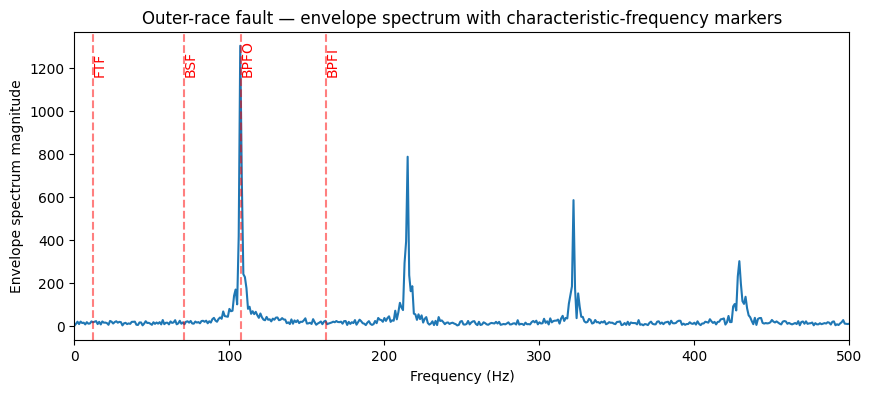

In [4]:
peak_freq, peak_amp = dominant_envelope_peak(x, sample_rate)
print(f'Dominant peak: {peak_freq:.2f} Hz (amplitude {peak_amp:.3f})')
print(f"BPFO: {char_freqs['BPFO']:.2f} Hz")
